In [86]:
# Local laptop control for firmware

import serial
import matplotlib.pyplot as plt

# from sensors.camera.camera_readings import get_frame, parse_frame

from websocket import create_connection
import json

import pandas as pd
import time
import requests
import numpy as np

In [ ]:
ESP_IP = requests.get("https://kv.wfeng.dev/bill-esp32-drone-addr").text.strip()
print(f"ESP IP: {ESP_IP}")

ESP IP: 192.168.86.28


In [84]:
print(f"Connecting to ESP...")
ws = create_connection(f"ws://{ESP_IP}/ws")
print("Connected!")

def set_throttle(throttle):
    ws.send(str(throttle))

try:
    readings = []

    for throttle in range(300, 1000, 50):
        print(f"Setting throttle to {throttle}")
        set_throttle(throttle)

        for _ in range(30):
            data = json.loads(ws.recv())
            readings.append({"throttle": throttle, **data})
            time.sleep(0.016)

        # break

finally:
    ws.send("0")
    ws.close()

Connecting to ESP...
Connected!
Setting throttle to 300
Setting throttle to 350
Setting throttle to 400
Setting throttle to 450
Setting throttle to 500
Setting throttle to 550
Setting throttle to 600
Setting throttle to 650
Setting throttle to 700
Setting throttle to 750
Setting throttle to 800
Setting throttle to 850
Setting throttle to 900
Setting throttle to 950


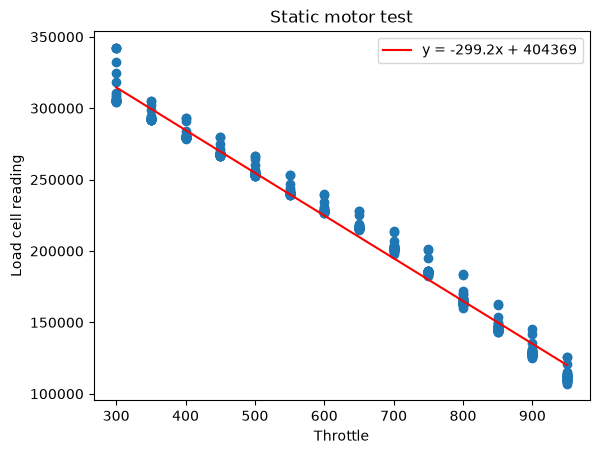

In [92]:
df = pd.DataFrame(readings)

m, b = np.polyfit(df.throttle, df.force, 1)
x = np.linspace(df.throttle.min(), df.throttle.max(), 100)

plt.scatter(df.throttle, df.force)
plt.plot(x, m * x + b, color="red", label=f"y = {m:.1f}x + {b:.0f}")
plt.ylabel("Load cell reading")
plt.xlabel("Throttle")
plt.title("Static motor test")

plt.legend()
plt.show()